In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

import h5py

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def take_abs(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )

    return np.sqrt(mean.T[1]**2 + mean.T[2]**2)


def take_real(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[1]


def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
at=0.2

In [4]:
pwd

'/mnt/baracuda_14/qed3/qed3/src/both_3d'

In [25]:
f = h5py.File("glue_ylm.hdf5", "r")
print( f.keys() )
# f1pt=f['1pt'][()]
corrs=f['corr'][()][:10000]
# f.create_dataset("corr", data=corrs, dtype='f' )
# f.create_dataset("1pt", data=F1pts, dtype='f' )
f.close()

<KeysViewHDF5 ['1pt', 'corr']>


In [6]:
Nf=2

# gsq="8.000000"
gsq="2.000000"

# gsq="1.000000"
# gsq="0.500000"
# gsq="0.100000"

# nu0="2.000000"
nu0="1.000000"

nu1=nu0 # "1.000000"
# nu1="2.000000"


at="0.200000"
Nt=96
L=1

In [7]:
label="data_Nf"+str(Nf)+"_gsq"+str(gsq)+"at"+str(at)+"nu0"+str(nu0)+"nt"+str(Nt)+"L"+str(L)
# label="data_gsq"+str(gsq)+"at"+str(at)+"nt"+str(Nt)+"L"+str(L)

In [8]:
dir1='/mnt/baracuda_14/qed3/qed3/src/both_3d/'
path = dir1+label

In [9]:
path

'/mnt/baracuda_14/qed3/qed3/src/both_3d/data_Nf2_gsq2.000000at0.200000nu01.000000nt96L1'

In [10]:
binsize=2

In [11]:
files_ = sorted(glob.glob(path+"/F_corr.*"), key=sorted) # @@@ ill ordered
files = np.array(files_)
iconfigs = [ int(fff.split('.')[-1]) for fff in natsorted(files)]
# iconfigs = [ int(fff.split('.')[-1]) for fff in natsorted(files)][170:]

corrs_=[]
F1pts_=[]
for i in iconfigs[10:]:
# for file in natsorted(files)[170:]:
    corr = np.loadtxt( path+"/F_corr."+str(i) )
    corr = (corr[1:int(Nt/2)] + np.flip( corr[int(Nt/2):Nt-1], axis=0 )).T
    F1pt = np.loadtxt( path+"/F."+str(i) ) # [0]
    corrs_.append( corr )
    F1pts_.append( F1pt )

corrs = np.array(corrs_)
F1pts = np.array(F1pts_)

# plt.plot( np.mean(corrs, axis=1) )
# jks_.append([igam,jk.mean(),jk.err()])
    
# plt.ylim(0.0045, 0.0046)
plt.show()

In [26]:
corrs.shape

(10000, 81, 47)

In [29]:
nops=9 # 9
tcut=6
dt=1

In [30]:
# prod1pt = np.array( np.kron( mean1pt, mean1pt ) )
mean_corr = np.mean(corrs, axis=0)
conn = mean_corr # -prod1pt).T
matC1 = np.array(np.split( conn, nops, axis=0 ))
matC = np.transpose(matC1, (-1, 0, -2))
matCT = np.transpose(matC, (0, 2, 1))
matCA = 0.5*(matC+matCT)

In [31]:
at=float(at)

In [32]:
at

0.2

In [33]:
eigvals_ = []
for t in range(1,tcut):
    sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    eigval, eigvec = np.linalg.eigh(matM)
    eigvals_.append( eigval )

eigvals = np.array(eigvals_)
-np.log(eigvals)/at

array([[ 3.4814117 ,  3.1549416 ,  3.1169634 ,  2.9621053 ,  2.6410966 ,
         2.4407542 ,  2.4291263 ,  2.2338042 ,  1.6367668 ],
       [ 3.7822616 ,  3.476883  ,  3.241094  ,  2.9383705 ,  2.605006  ,
         2.3896277 ,  2.2548347 ,  2.0471728 ,  1.540197  ],
       [ 4.7061753 ,  3.9678006 ,  3.2522392 ,  3.0500438 ,  2.5627103 ,
         2.3229525 ,  2.2021    ,  1.7609389 ,  1.3892647 ],
       [ 3.5904968 ,  3.422321  ,  3.0716634 ,  2.6393092 ,  2.3808548 ,
         2.2746365 ,  2.0258389 ,  1.9157065 ,  1.4150443 ],
       [ 7.0479856 ,  4.586508  ,  2.6209044 ,  2.1950452 ,  1.6898215 ,
         1.56964   ,  1.0770276 ,  0.33946785, -1.3175379 ]],
      dtype=float32)

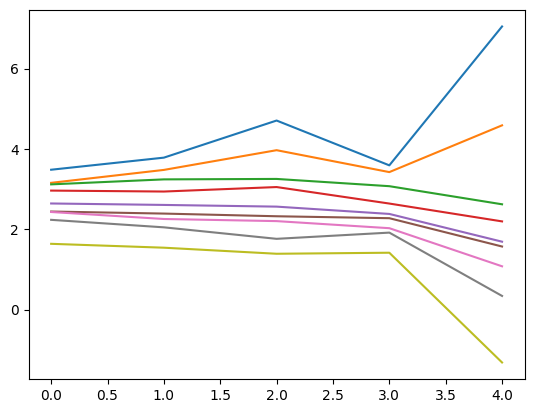

In [34]:
plt.plot( -np.log(eigvals)/at )

In [35]:
def gevp(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    matC1 = np.array(np.split( conn, nops, axis=0 ))
    matC = np.transpose(matC1, (-1, 0, -2))
    matCT = np.transpose(matC, (0, 2, 1))
    matCA = 0.5*(matC+matCT)

    eigvals_ = []
    for t in range(1,tcut):
        sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
        matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
        eigval, eigvec = np.linalg.eigh(matM)
        eigvals_.append( eigval )
    eigvals = np.array(eigvals_)

    return -np.log(eigvals)/at

In [36]:
nbins=40

In [37]:
jk = Jackknife( corr.shape[0], int( corr.shape[0]/nbins ) )
jk.set( gevp, corr )
jk.do_it()

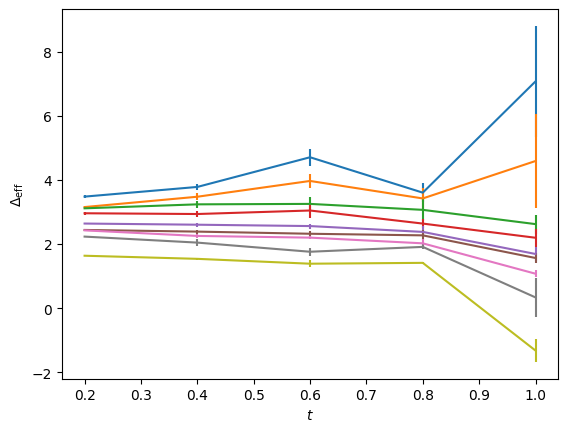

In [38]:
xx = np.arange(1,tcut)*at
for i in range(nops):
    plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}$")

plt.savefig("spectrum.pdf")

In [39]:
def twostates( t, m0, A, Dm ):
    return m0 + A*np.exp(-Dm*t)

def onestate( t, m0 ):
    return m0

In [ ]:
i=nops-1
plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

In [39]:
iop=nops-1
fitm=2
fitM=4

xx2=xx[fitm:fitM]
yy2=jk.mean().T[iop][fitm:fitM]
dyy2=jk.err().T[iop][fitm:fitM]

opt1=sp.optimize.curve_fit( onestate, xx2, yy2, sigma=dyy2, absolute_sigma=True )

In [40]:
def gevp_fit(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    matC1 = np.array(np.split( conn, nops, axis=0 ))
    matC = np.transpose(matC1, (-1, 0, -2))
    matCT = np.transpose(matC, (0, 2, 1))
    matCA = 0.5*(matC+matCT)

    eigvals_ = []
    for t in range(1,tcut):
        sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
        matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
        eigval, eigvec = np.linalg.eigh(matM)
        eigvals_.append( eigval )
    eigvals = np.array(eigvals_)

    yy = (-np.log(eigvals)/at).T
    # print(yy)
    yyy = yy[iop][fitm:fitM]
    # print(yyy)
    dyyy = dyy2

    opt = sp.optimize.curve_fit( onestate, xx2, yyy, sigma=dyyy, p0=opt1[0], absolute_sigma=True )
    # print(opt[0])

    return opt[0]

In [41]:
jk2 = Jackknife( corr.shape[0], int( corr.shape[0]/nbins ) )
jk2.set( gevp_fit, corr )
jk2.do_it()

In [42]:
format_print_w_exact( np.sqrt(2.0), jk2.mean()[0], jk2.err()[0] )

'1.412(37): 0.064 sigma'